![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

 ## 0.1 Import libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

## 0.2 Compact Models for simulations

### 0.2.1. Waveguide compact model (Lab1. LO4)

We start from the waveguide's effective index second degree polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Or from the parameters derived from the polynomial coefficients: 
 
$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmmission through the waveguide should be modeled as: 

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$
With  
$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scatter parameter circuit simulator, to implement simulations in the frequency (wavelength) domain. The following cell demonstrates how to define the most basic component transfer function: 

In [21]:
# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um))
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um (Experimental value)
# D: Dispersion parameter (s^2/m)
def waveguide(wl=1.55, wl0=1.55, neff=1.6072, ng=2.0, length=10.0, loss=0.0, D=0) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1-ng)/wl0
    n3 = -D*c0/(2*wl0)
    neff = n1 + n2*dwl + n3*dwl**2
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### 0.2.2. Coupler compact model (Lab2 LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters you found in your Laboratory 2. The model we are going to implement does not take into account if the coupler is an MMI or a Directional Coupler, it just use as parameters the coupling coefficient to calculate the output power at each port. 

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$

In [22]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient (between 0 and 1)
# You MUST update the model with the parameters you found in your Laboratory 2: 
# Excess loss, actual phase shift.
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions)
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.1. MZI Circuit Model

Using SAX library, we can now define the components, connections and models needed to build our circuit. Let's start with the MZI: 

<img src="mzi.png" alt="mzi circuit" width="600">

We will need two couplers and two waveguides: 


In [23]:
# MZI Circuit
# We will define instances, connections and ports for the MZI circuit using the SAX library.
# We will use the coupler and waveguide models defined above.
mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },
        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },
        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },
    # Important! Provide here the models for the components used in the circuit
    # Here we use the coupler and waveguide functions defined above
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


Using this circuit model, it is possible now to perform simulations to obtain the MZI response:

Text(0, 0.5, '|H|^2 [dB]')

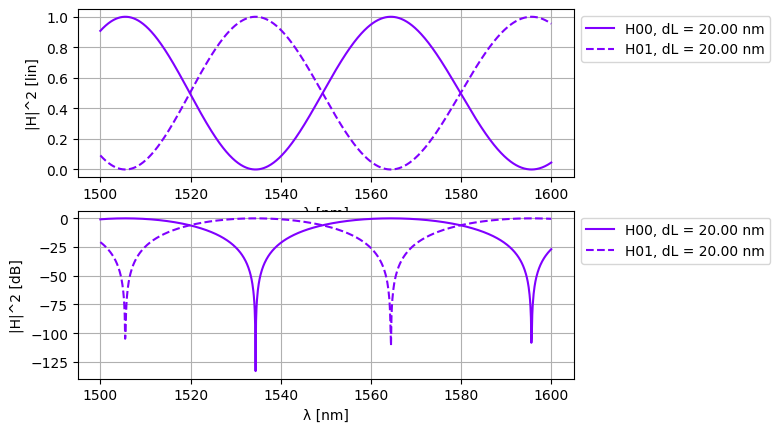

In [24]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([20,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section with certain variations for LO1a,1b,2 and 3.

## LO.1a Perfectly balanced MZI.

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1004/2469550147.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, jnp.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1004/2469550147.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, jnp.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1004/2469550147.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wl * 1

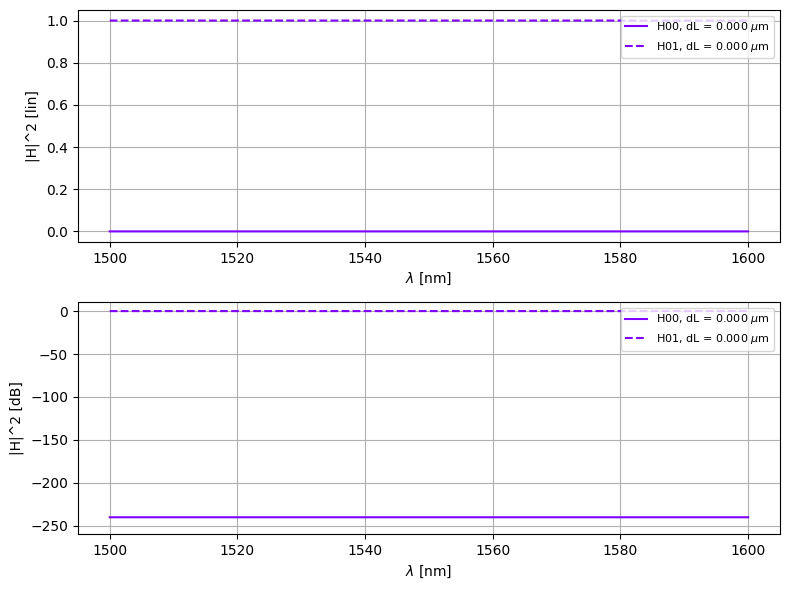

In [25]:
# LO1a - Perfectly balanced MZI
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)

# 2. MZI Equilibrado
delta_l_v = np.array([0.0]) 
l_base = 10.0

mzi_test = []
n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):
    # Simulamos el MZI
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    
    # Extraemos parámetros S
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    eps = 1e-12 
    H00_dB = 20.0 * jnp.log10(jnp.abs(H00) + eps)
    H01_dB = 20.0 * jnp.log10(jnp.abs(H01) + eps)

    ax[0].plot(wl * 1e3, jnp.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
    ax[0].plot(wl * 1e3, jnp.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8, loc='upper right', bbox_to_anchor=(1, 1))
    ax[i].set_xlabel("$\lambda$ [nm]")

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")
ax[1].set_ylim(-260, 10) 

plt.tight_layout()
plt.show()

## LO.1b Unbalanced MZI.

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1004/1568109557.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, jnp.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
/tmp/ipykernel_1004/1568109557.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, jnp.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")
/tmp/ipykernel_1004/1568109557.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
/tmp/ipykernel_100

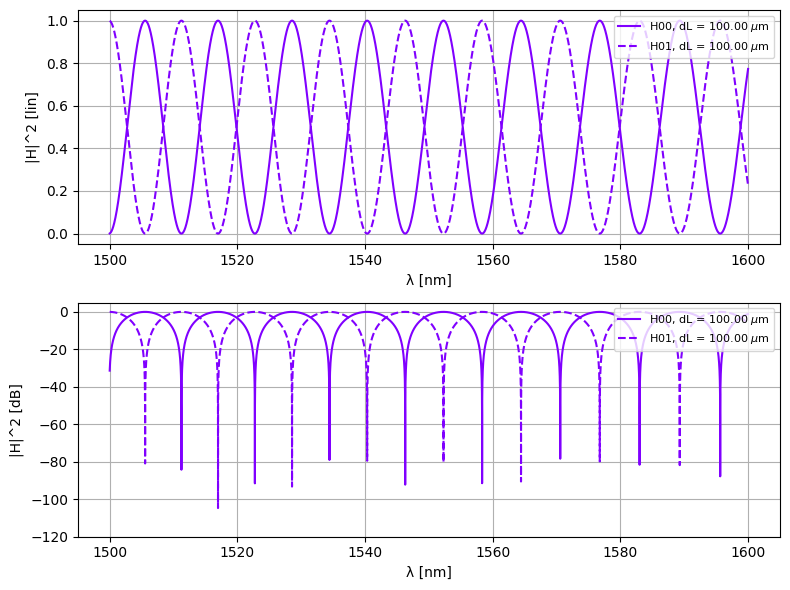

In [26]:
# Wavelengths to simulate (step 0.001 nm)
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)

# Length values to simulate
delta_l_v = np.array([100.0])
l_base = 10.0

mzi_test = []
n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):
    # Simulate unbalanced MZI
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    
    # Extract S-parameters
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    eps = 1e-12
    H00_dB = 20.0 * jnp.log10(jnp.abs(H00) + eps)
    H01_dB = 20.0 * jnp.log10(jnp.abs(H01) + eps)

    ax[0].plot(wl * 1e3, jnp.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
    ax[0].plot(wl * 1e3, jnp.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8, loc='upper right', bbox_to_anchor=(1, 1))
    ax[i].set_xlabel("λ [nm]")

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")
ax[1].set_ylim(-120, 5) 

plt.tight_layout()
plt.show()

## LO.2 MZI Design

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1004/3941439492.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax[0, 0].plot(wl * 1e3, jnp.abs(H00)**2, "-", color="blue", label=f"H00, dL={delta_l:.3f} $\mu$m")
/tmp/ipykernel_1004/3941439492.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax[1, 0].plot(wl * 1e3, H00_dB, "-", color="blue", label=f"H00, dL={delta_l:.3f} $\mu$m")


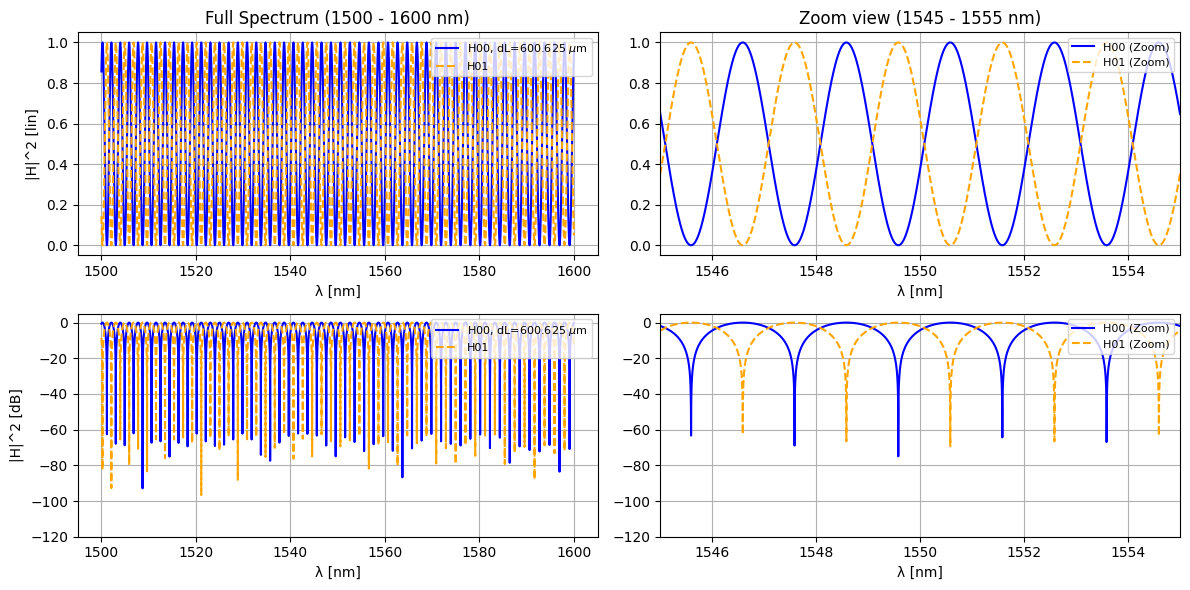

In [27]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)

delta_l_v = np.array([600.625]) 
l_base = 10.0

fig, ax = plt.subplots(2, 2, figsize=(12, 6))

for delta_l in delta_l_v:
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    eps = 1e-12
    H00_dB = 20.0 * jnp.log10(jnp.abs(H00) + eps)
    H01_dB = 20.0 * jnp.log10(jnp.abs(H01) + eps)

    # Left Column: Full Range
    ax[0, 0].plot(wl * 1e3, jnp.abs(H00)**2, "-", color="blue", label=f"H00, dL={delta_l:.3f} $\mu$m")
    ax[0, 0].plot(wl * 1e3, jnp.abs(H01)**2, "--", color="orange", label=f"H01")
    
    ax[1, 0].plot(wl * 1e3, H00_dB, "-", color="blue", label=f"H00, dL={delta_l:.3f} $\mu$m")
    ax[1, 0].plot(wl * 1e3, H01_dB, "--", color="orange", label=f"H01")

    # Right Column: Zoom (1545 nm - 1555 nm)
    ax[0, 1].plot(wl * 1e3, jnp.abs(H00)**2, "-", color="blue", label=f"H00 (Zoom)")
    ax[0, 1].plot(wl * 1e3, jnp.abs(H01)**2, "--", color="orange", label=f"H01 (Zoom)")

    ax[1, 1].plot(wl * 1e3, H00_dB, "-", color="blue", label=f"H00 (Zoom)")
    ax[1, 1].plot(wl * 1e3, H01_dB, "--", color="orange", label=f"H01 (Zoom)")

# Format Full Range (Left)
for i in range(2):
    ax[i, 0].grid(visible=True)
    ax[i, 0].set_xlabel("λ [nm]")
    ax[i, 0].legend(fontsize=8, loc='upper right')

# Format Zoom (Right)
for i in range(2):
    ax[i, 1].grid(visible=True)
    ax[i, 1].set_xlabel("λ [nm]")
    ax[i, 1].set_xlim(1545, 1555) 
    ax[i, 1].legend(fontsize=8, loc='upper right')

ax[0, 0].set_ylabel("|H|^2 [lin]")
ax[1, 0].set_ylabel("|H|^2 [dB]")
ax[0, 0].set_title("Full Spectrum (1500 - 1600 nm)")
ax[0, 1].set_title("Zoom view (1545 - 1555 nm)")

ax[1, 0].set_ylim(-120, 5)
ax[1, 1].set_ylim(-120, 5)

plt.tight_layout()
plt.show()

## LO.3 Delay imbalance with loss.

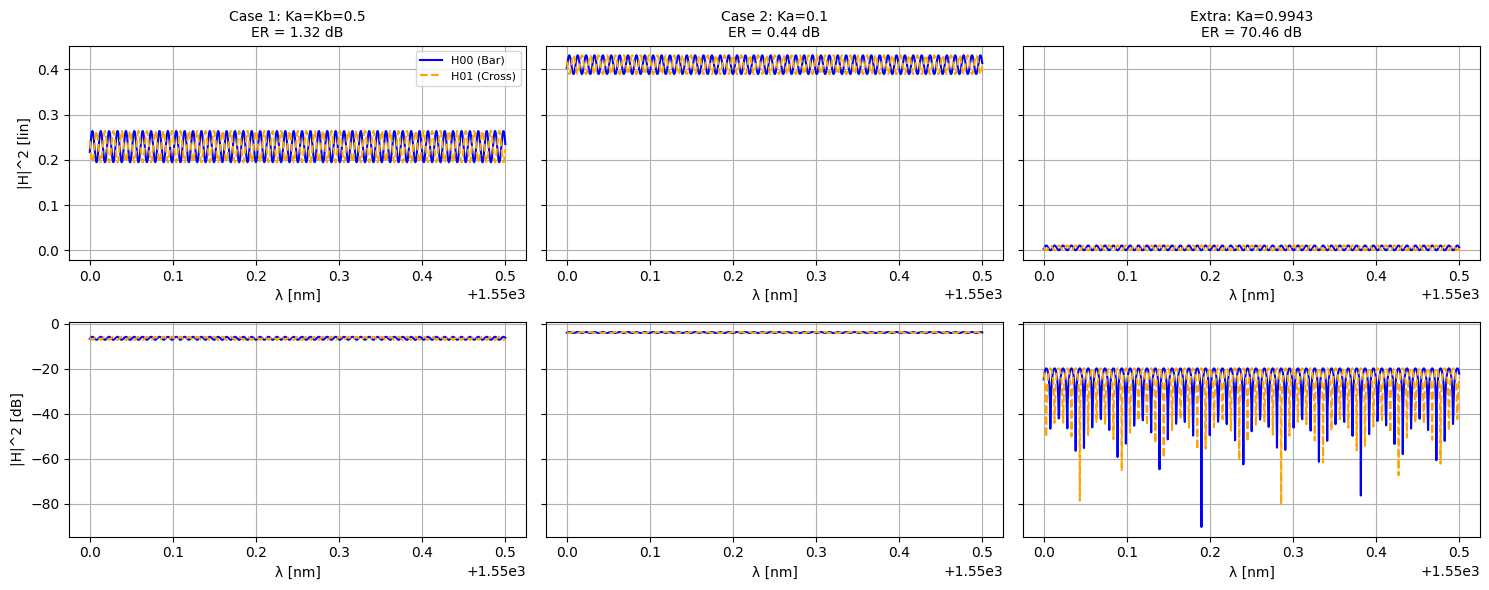

Extra loss in long arm = 22.38 dB
Matched input coupling Ka = 0.994258


In [28]:
import sax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Component Models
def waveguide_lo3(wl=1.55, wl0=1.55, neff=2.38, ng=4.25, length=1000.0, loss=4.0, D=0.0) -> sax.SDict:
    loss_db_um = loss / 1e4
    dwl = wl - wl0
    n2 = (neff - ng) / wl0
    n3 = 0.0 if D == 0 else -D * 299792458.0 / (2 * wl0)
    neff_wl = neff + n2 * dwl + n3 * dwl**2
    
    phase = 2 * jnp.pi * neff_wl * length / wl
    transmission = 10 ** (-loss_db_um * length / 20) * jnp.exp(1j * phase)
    return sax.reciprocal({("in0", "out0"): transmission})

def coupler(coupling=0.5):
    kappa = coupling**0.5
    tau = (1 - coupling)**0.5
    return sax.reciprocal({
        ("in0", "out0"): tau, ("in0", "out1"): 1j * kappa,
        ("in1", "out0"): 1j * kappa, ("in1", "out1"): tau,
    })

#  Circuit Definition
mzi_lo3, _ = sax.circuit(
    netlist={
        "instances": {
            "coup_E": "coupler",
            "wg_N": "waveguide_lo3",
            "wg_S": "waveguide_lo3",
            "coup_W": "coupler",
        },
        "connections": {
            "coup_E,out0": "wg_S,in0", "wg_S,out0": "coup_W,in0",
            "coup_E,out1": "wg_N,in0", "wg_N,out0": "coup_W,in1",
        },
        "ports": {
            "in0": "coup_E,in0", "out0": "coup_W,out0", "out1": "coup_W,out1",
        },
    },
    models={"coupler": coupler, "waveguide_lo3": waveguide_lo3}
)

# Parameters & Simulation setup
wl = jnp.arange(1.550, 1.5505 + 0.0000005, 0.0000005)
L_base = 1000.0
delta_L = 55960.0840224255
L_long = L_base + delta_L
loss = 4.0 

# Extra loss matching math
loss_db_um = loss / 1e4
extra_loss_db = loss_db_um * delta_L
r_power = 10 ** (-extra_loss_db / 10)
Ka_match = 1 / (1 + r_power)

cases = [
    ("Case 1: Ka=Kb=0.5", 0.5, 0.5),
    ("Case 2: Ka=0.1", 0.1, 0.5),
    (f"Extra: Ka={Ka_match:.4f}", Ka_match, 0.5),
]

# Simulation & Plotting (3 Column Layout)
fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharey='row')
eps = 1e-20

for col, (label, Ka, Kb) in enumerate(cases):
    
    # Run simulation for the specific case
    res = mzi_lo3(
        wl=wl,
        wg_S={"length": L_base},
        wg_N={"length": L_long},
        coup_E={"coupling": Ka},
        coup_W={"coupling": Kb},
    )
    
    H00 = res["in0", "out0"]
    H01 = res["in0", "out1"]
    
    P00_db = 10 * jnp.log10(jnp.abs(H00)**2 + eps)
    P01_db = 10 * jnp.log10(jnp.abs(H01)**2 + eps)
    
    # Calculate Extinction Ratio (ER)
    ER00 = jnp.max(P00_db) - jnp.min(P00_db)
    
    # Plot Linear
    ax[0, col].plot(wl * 1e3, jnp.abs(H00)**2, "-", color="blue", label="H00 (Bar)")
    ax[0, col].plot(wl * 1e3, jnp.abs(H01)**2, "--", color="orange", label="H01 (Cross)")
    ax[0, col].set_title(f"{label}\nER = {ER00:.2f} dB", fontsize=10)
    
    # Plot dB
    ax[1, col].plot(wl * 1e3, P00_db, "-", color="blue")
    ax[1, col].plot(wl * 1e3, P01_db, "--", color="orange")
    
    for row in range(2):
        ax[row, col].grid(True)
        ax[row, col].set_xlabel("λ [nm]")

ax[0, 0].set_ylabel("|H|^2 [lin]")
ax[1, 0].set_ylabel("|H|^2 [dB]")
ax[0, 0].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Print console results matching the report requirements
print(f"Extra loss in long arm = {extra_loss_db:.2f} dB")
print(f"Matched input coupling Ka = {Ka_match:.6f}")

## LO.4. Ring Resonators.

### 1.1. Ring Resonator Circuit Models

We can implement two different variations for the Ring Resonator. The simple ring that consist of a coupler connected with a waveguide (ring_ap), and the double bus ring that needs an extra coupler and the corresponding waveguides to make connections between them (ring_2bus): 

<img src="rings.png" alt="mzi circuit" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [4]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

[18:21:03] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=714490;file:///home/celia/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=915728;file:///home/celia/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Then we can test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

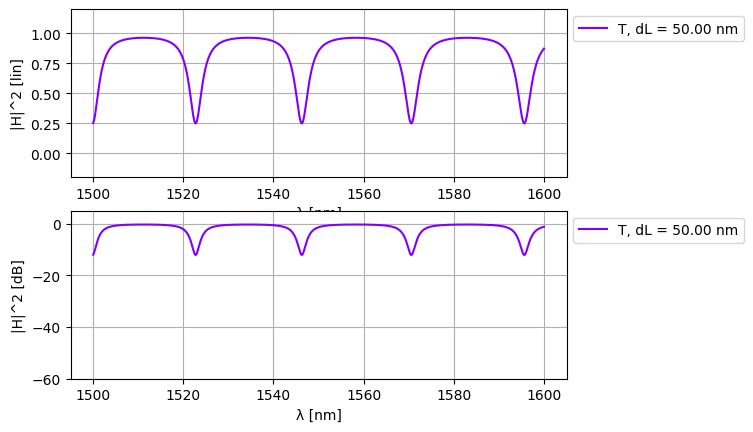

In [5]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

## LO.4

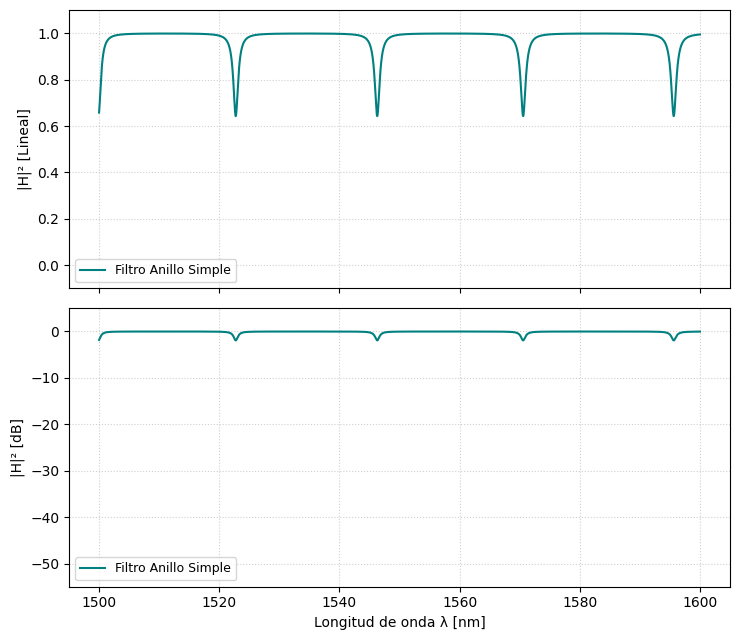

=== RESULTADOS DE DISEÑO ===
Perímetro del Anillo (L): 50.00 um
FSR Teórico Calculado: 24.03 nm


In [6]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

def calcular_allpass_anillo(wavelen=1.55, lambda_ref=1.55, n_efectivo=1.6072, n_grupo=2.0, L_ring=50.0, alpha_loss=0.02, kappa_sq=0.025):

    delta_wvl = wavelen - lambda_ref
    slope_neff = (n_efectivo - n_grupo) / lambda_ref
    neff_dispersivo = n_efectivo + (slope_neff * delta_wvl)

    fase_vuelta = (2 * jnp.pi * neff_dispersivo * L_ring) / wavelen
    
    attenuation = 10 ** (-alpha_loss * L_ring / 20)  
    transmission_coeff = jnp.sqrt(1.0 - kappa_sq)    

    termino_fase = jnp.exp(1j * fase_vuelta)
    T_circuit = (transmission_coeff - attenuation * termino_fase) / (1.0 - transmission_coeff * attenuation * termino_fase)

    return {("in0", "out0"): T_circuit}


wvl_vector = jnp.linspace(1.50, 1.60, 10000)
perimetro = 50.0       
k_acoplo = 0.025       
perdidas_prop = 0.02   


datos_simulacion = calcular_allpass_anillo(
    wavelen=wvl_vector,
    L_ring=perimetro,
    alpha_loss=perdidas_prop,
    kappa_sq=k_acoplo
)

H_out = datos_simulacion["in0", "out0"]
potencia_lin = np.abs(H_out) ** 2
potencia_dB = 10.0 * jnp.log10(potencia_lin + 1e-15) # Tolerancia numérica antipánico


# GENERACIÓN DE GRÁFICAS

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.5), sharex=True)

axes[0].plot(wvl_vector * 1e3, potencia_lin, color="#008080", linewidth=1.5, label="Filtro Anillo Simple")
axes[0].set_ylabel("|H|² [Lineal]")
axes[0].set_ylim([-0.1, 1.1])

axes[1].plot(wvl_vector * 1e3, potencia_dB, color="#008080", linewidth=1.5, label="Filtro Anillo Simple")
axes[1].set_ylabel("|H|² [dB]")
axes[1].set_xlabel("Longitud de onda λ [nm]")
axes[1].set_ylim([-55, 5])

for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

wvl_central = 1.55
idx_grupo = 2.0
calculo_fsr = (wvl_central ** 2) / (idx_grupo * perimetro)

print(f"=== RESULTADOS DE DISEÑO ===")
print(f"Perímetro del Anillo (L): {perimetro:.2f} um")
print(f"FSR Teórico Calculado: {calculo_fsr * 1e3:.2f} nm")

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers

In [7]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

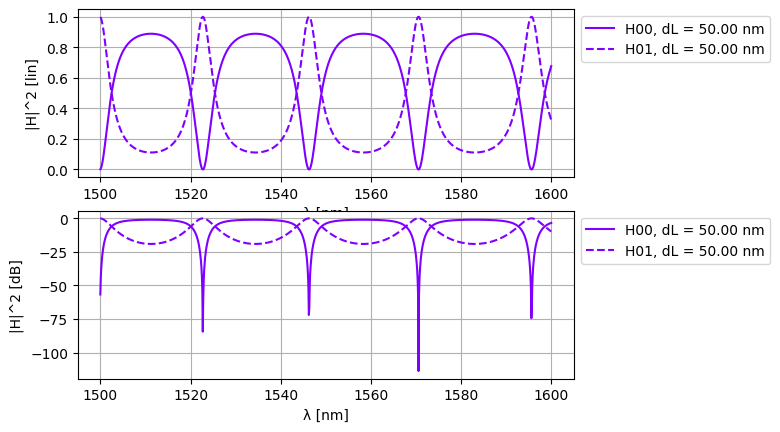

In [8]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.0})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


The resulting interference pattern again exhibits a periodic behavior. We define again the **free spectral range** (FSR), which should satisfy in this case the relationship:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

Where $L_r$ is the ring perimeter. Note that in our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.

#### **HINT**

You can perform parametric variations using the codes provided by us, for instance, check this casi in which we performed a loss sweep. 

Text(0, 0.5, '|H|^2 [dB]')

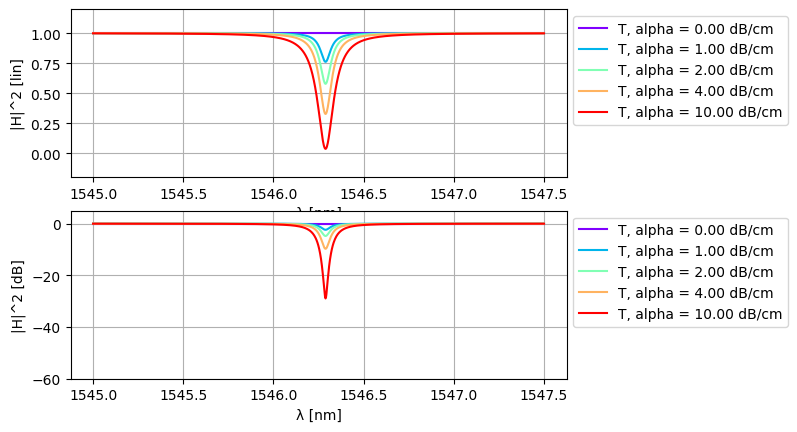

In [ ]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LOs4, 5, and 6.

## LO.5

Coeficiente K = 0.005 -> ER = 0.23 dB
Coeficiente K = 0.025 -> ER = 1.19 dB
Coeficiente K = 0.050 -> ER = 2.42 dB
Coeficiente K = 0.100 -> ER = 5.08 dB


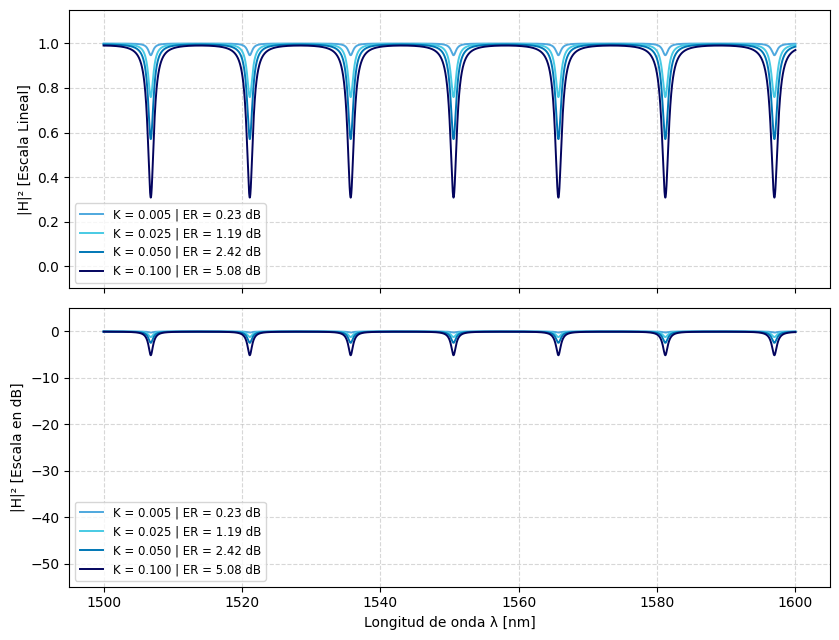


PARÁMETROS CRÍTICOS
Perímetro: 80.0833 um
Factor (a): 0.83160
K_crítico: 0.30843


In [30]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

def simular_anillo_allpass(wvl_array, lambda_zero=1.55, eff_index=1.6072, gr_index=2.0, total_length=80.0, db_loss=0.02, power_coupling=0.025):
    
    
    delta_wvl = wvl_array - lambda_zero
    dispersion_slope = (eff_index - gr_index) / lambda_zero
    neff_corrected = eff_index + (dispersion_slope * delta_wvl)

    opt_phase = (2 * jnp.pi * neff_corrected * total_length) / wvl_array
    
    loss_factor = 10 ** (-db_loss * total_length / 20)
    transmission_factor = jnp.sqrt(1.0 - power_coupling)

    phase_term = jnp.exp(1j * opt_phase)
    transmission_matrix = (transmission_factor - loss_factor * phase_term) / (1.0 - transmission_factor * loss_factor * phase_term)

    return {("in0", "out0"): transmission_matrix}

λ0 = 1.55                    
n_grupo = 2.0               
fsr_objetivo = 15.0 * 1e-3   

perimetro_disenado = (λ0 ** 2) / (n_grupo * fsr_objetivo)

espectro_wl = jnp.linspace(1.50, 1.60, 10000)
atenuacion_lineal = 0.02
lista_K = np.array([0.005, 0.025, 0.05, 0.1])

fig, axes = plt.subplots(2, 1, figsize=(8.5, 6.5), sharex=True)
colores_oceano = ["#4ea8de", "#48cae4", "#0077b6", "#03045e"]  



for idx, k_acoplo in enumerate(lista_K):
    circuito_anillo = simular_anillo_allpass(
        wvl_array=espectro_wl,
        total_length=perimetro_disenado,
        db_loss=atenuacion_lineal,
        power_coupling=k_acoplo
    )
    
    H_transfer = circuito_anillo["in0", "out0"]
    pot_lineal = np.abs(H_transfer) ** 2
    pot_log = 10.0 * jnp.log10(pot_lineal + 1e-20)
    
    # Cálculo del ER
    extinction_ratio = np.max(pot_log) - np.min(pot_log)
    print(f"Coeficiente K = {k_acoplo:.3f} -> ER = {extinction_ratio:.2f} dB")
    
    
    axes[0].plot(espectro_wl * 1e3, pot_lineal, color=colores_oceano[idx], linewidth=1.4, label=f"K = {k_acoplo:.3f} | ER = {extinction_ratio:.2f} dB")
    axes[1].plot(espectro_wl * 1e3, pot_log, color=colores_oceano[idx], linewidth=1.4, label=f"K = {k_acoplo:.3f} | ER = {extinction_ratio:.2f} dB")

axes[0].set_ylim([-0.1, 1.15])
axes[0].set_ylabel("|H|² [Escala Lineal]")
axes[1].set_ylim([-55, 5])
axes[1].set_ylabel("|H|² [Escala en dB]")
axes[1].set_xlabel("Longitud de onda λ [nm]")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="lower left", fontsize=8.5)

plt.tight_layout()
plt.show()


perdida_vuelta_amplitud = 10 ** (-atenuacion_lineal * perimetro_disenado / 20)
k_critico_teorico = 1.0 - (perdida_vuelta_amplitud ** 2)

print("\nPARÁMETROS CRÍTICOS")
print(f"Perímetro: {perimetro_disenado:.4f} um")
print(f"Factor (a): {perdida_vuelta_amplitud:.5f}")
print(f"K_crítico: {k_critico_teorico:.5f}")

## LO.6a

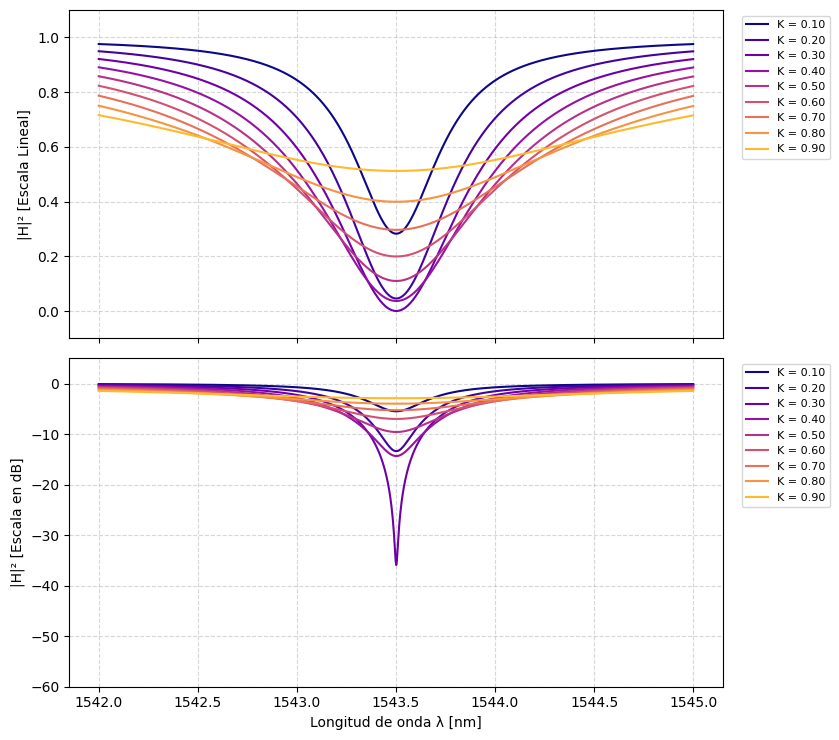

In [11]:
import numpy as np
import matplotlib.pyplot as plt


wl_nm = np.linspace(1542.0, 1545.0, 1000)
longitudes_onda = wl_nm * 1e-3  # Conversión a micras

L_cavidad = 75.0        # um
coef_atenuacion = 0.02  # dB/cm
wl0 = 1.5435            


vector_K = np.linspace(0.1, 0.9, 9)

fig, ejes = plt.subplots(2, 1, figsize=(8.5, 7.5), sharex=True)
mapa_colores = plt.cm.plasma(np.linspace(0, 0.85, len(vector_K)))

for indice, k_factor in enumerate(vector_K):
    
    
    dwl = longitudes_onda - wl0
    
    phi = (2 * np.pi * 3.0 * L_cavidad / longitudes_onda) * (1.0 - 0.45 * (dwl / wl0))
    phi = phi - phi[500] 

    a = 10 ** (-coef_atenuacion * L_cavidad / 20)
    t = np.sqrt(1.0 - k_factor)

    T_complex = (t - a * np.exp(1j * phi)) / (1.0 - t * a * np.exp(1j * phi))
    
    pot_lineal = np.abs(T_complex) ** 2
    pot_dB = 10.0 * np.log10(pot_lineal + 1e-20)

    ejes[0].plot(wl_nm, pot_lineal, linestyle="-", color=mapa_colores[indice], label=f"K = {k_factor:.2f}")
    ejes[1].plot(wl_nm, pot_dB, linestyle="-", color=mapa_colores[indice], label=f"K = {k_factor:.2f}")

ejes[0].set_ylim([-0.1, 1.1])
ejes[1].set_ylim([-60, 5])
ejes[0].set_ylabel("|H|² [Escala Lineal]")
ejes[1].set_ylabel("|H|² [Escala en dB]")
ejes[1].set_xlabel("Longitud de onda λ [nm]")

for ax in ejes:
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

## LO.6b


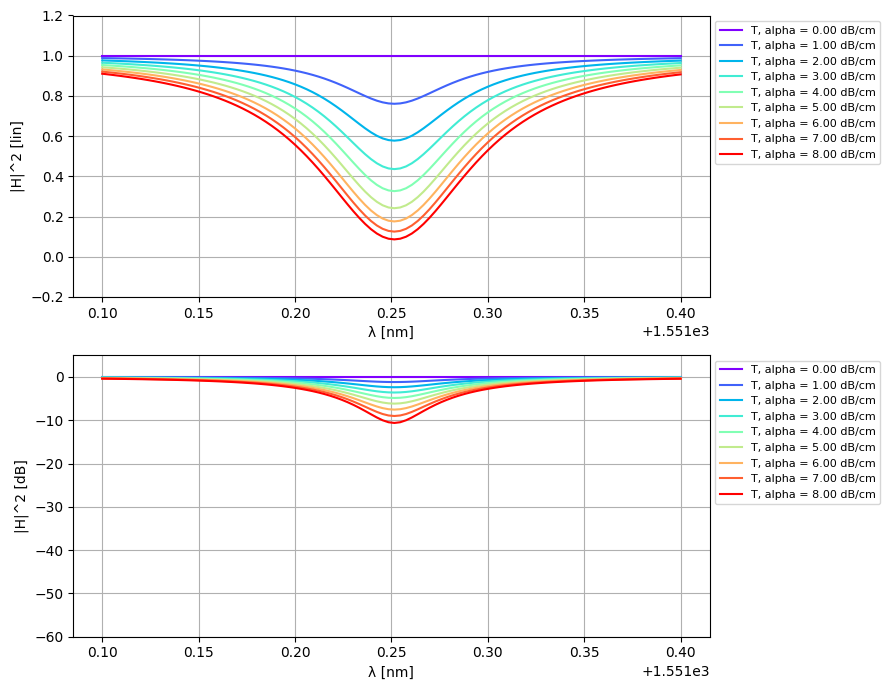

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


wl = np.linspace(1.5511, 1.5514, 100)


loss_dBum = 1e-4 * np.linspace(0, 8, 9)
n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))


ring_perimeter = 75.0
coupling = 0.025
wl0 = 1.55125  
neff = 1.6072
ng = 2.0

fig, ax = plt.subplots(2, 1, figsize=(9, 7))

for i, loss in enumerate(loss_dBum):
    
    dwl = wl - wl0
    n2 = (neff - ng) / wl0
    neff_wl = neff + n2 * dwl
    
    phi = (2 * np.pi * neff_wl * ring_perimeter / wl)
    phi = phi - phi[50] 
    
    a = 10 ** (-loss * ring_perimeter / 20)
    t = np.sqrt(1.0 - coupling)
    
    T_complex = (t - a * np.exp(1j * phi)) / (1.0 - t * a * np.exp(1j * phi))
    
    T_linear = np.abs(T_complex) ** 2
    T_dB = 10.0 * np.log10(T_linear + 1e-20)
    
    ax[0].plot(wl * 1e3, T_linear, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")
    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")


ax[0].set_ylim([-0.2, 1.2])
ax[1].set_ylim([-60, 5])
ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

for i in range(0, 2):
    ax[i].grid(visible=True)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

plt.tight_layout()
plt.show()